In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv('ToyotaCorolla.csv')

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non-null   int64 


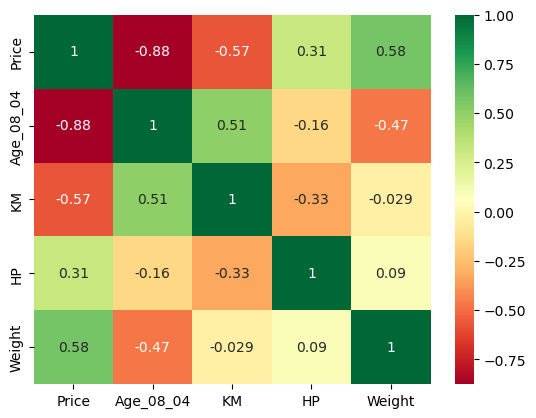

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data[['Price', 'Age_08_04', 'KM', 'HP', 'Weight']].corr(), annot=True, cmap='RdYlGn')
plt.show()

## Как вы предобрабатывали данные?
Я просмотрел датасет на наличие пустых значений, а также отобрал наиболее важные признаки (пробег авто, возраст)

## Что вы поняли, проведя EDA?
Как оказалось, наибольшим образом коррелирует цена авто с его возрастом (отрицательная зависимость) и его вес (положительная)

In [4]:
columns_to_drop = [col for col in data.columns if data[col].nunique() == 1]

data_copy = data.copy()

data_copy.drop(columns=['Id'] + columns_to_drop, errors='ignore', inplace=True)

time_columns_to_drop = ['Mfg_Month', 'Mfg_Year']
data_copy.drop(columns=time_columns_to_drop, errors='ignore', inplace=True)

data_copy = pd.get_dummies(data_copy, columns=['Fuel_Type'], drop_first=True, dtype=int)

data_copy.drop(columns=['Model', 'Color'], errors='ignore', inplace=True)

## Как вы работали с признаками? 
Для начала я создал копию датасета, после этого я удалял некоторые признаки, а один из них разбил на два столбца, заполненных нулями и единицами (get_dummies)

## Какие признаки вы добавили, изменили и почему?
Как я сказал выше, я изменил признак с видом топлива на два, либо дизельный, либо топливный автомобиль через метод get_dummies. 

## Какие признаки вы удалили и почему?
Я удалил столбец ID, так как модель будет пытаться искать связь между номером строки и другими признаками, где её нет Так же есть шанс переобучения. Столбцы с временем были удалены в пользу одного (возраст в месяцах с момента сборки). Признаки модель и цвет были удалены, поскольку в первом случае очень муторно применять one-hot encoding, а во втором модель может найти ложные закономерности, ну и one-hot encoding расширит датасет на десятки колонок.

In [5]:
from sklearn.model_selection import train_test_split

y = data_copy['Price']
X = data_copy.drop(columns=['Price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Как вы разделили выборку?
По стандарту, 80 обучение 20 предсказывание

## Зачем мы это делаем?
Мы отделяем часть данных, чтобы посмотреть, как хорошо модель предскажет результат, и предскажет ли, а не просто зазубрит (переобучение). Если дать ей весь датасет, мы не сможем понять, как хорошо модель покажет себя на данных без "ответа".

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, predictions)
    results[name] = mae

results


{'Linear': 847.0060363001336,
 'Ridge': 846.3420934678223,
 'Lasso': 846.959441539636}

## Обучение

Обучение проводилось на стандартизированных признаках, чтобы коэффициенты регуляризации Ridge и Lasso работали корректно

## Сравнение скорости:

Обычная LinearRegression справилась мгновенно, так как в ней используется метод наименьших квадратов, не требующий долгих итераций

    Model  RMSE Train  RMSE Test  MAE Test  R2 Test
0  Linear     1121.81    1255.59    847.01    0.882
1   Ridge     1121.82    1254.30    846.34    0.882
2   Lasso     1121.81    1255.53    846.96    0.882


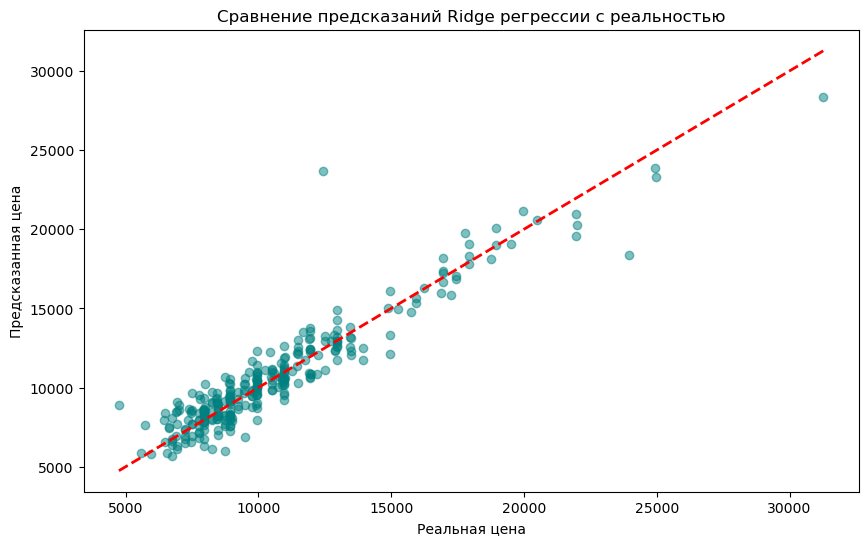

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = []

for name, model in models.items():
    train_preds = model.predict(X_train_scaled)
    test_preds = model.predict(X_test_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
    rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
    mae_test = mean_absolute_error(y_test, test_preds)
    r2_test = r2_score(y_test, test_preds)
    
    results.append({
        'Model': name,
        'RMSE Train': round(rmse_train, 2),
        'RMSE Test': round(rmse_test, 2),
        'MAE Test': round(mae_test, 2),
        'R2 Test': round(r2_test, 3)
    })

results_data = pd.DataFrame(results)
print(results_data)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, models['Ridge'].predict(X_test_scaled), alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Сравнение предсказаний Ridge регрессии с реальностью')
plt.show()


## Какие метрики использовали?
Использовались MAE для оценки средней ошибки в евро, RMSE для выявления крупных промахов и $R^2$ для определения доли объясненной вариации цены.

## На какой части выборки считали метрики?
Все ключевые метрики качества рассчитывались на тестовой (отложенной) выборке, которую модель не видела во время обучения.

## Какая модель справилась лучше?
Лучше всего справилась модель Ridge, так как благодаря L2-регуляризации она штрафует излишне большие веса признаков и выдает более стабильный результат.

## Насколько хорошие результаты?
Результаты отличные: модель адекватно предсказывает стоимость большинства авто, объясняя 88.2% дисперсии данных ($R^2 = 0.882$) со средней ошибкой всего 847 евро.

## Чем докажете отсутствие переобучения?
Ошибки на тренировочном и тестовом наборах практически совпадают, что доказывает высокую устойчивость модели.